In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/smart_home_energy_consumption_large.csv')

In [3]:
df.head()


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Home ID                   100000 non-null  int64  
 1   Appliance Type            100000 non-null  object 
 2   Energy Consumption (kWh)  100000 non-null  float64
 3   Time                      100000 non-null  object 
 4   Date                      100000 non-null  object 
 5   Outdoor Temperature (°C)  100000 non-null  float64
 6   Season                    100000 non-null  object 
 7   Household Size            100000 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 6.1+ MB


In [5]:
df.describe()


,Home ID,Energy Consumption (kWh),Outdoor Temperature (°C),Household Size
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,250.374980,1.499952,14.950135,3.001770
std,144.435367,1.181176,14.438755,1.417077
min,1.000000,0.100000,-10.000000,1.000000
25%,125.000000,0.590000,2.400000,2.000000
50%,250.000000,1.230000,14.900000,3.000000
75%,375.000000,1.870000,27.400000,4.000000
max,500.000000,5.000000,40.000000,5.000000


In [6]:
df.isnull().sum()

,0
Home ID,0
Appliance Type,0
Energy Consumption (kWh),0
Time,0
Date,0
Outdoor Temperature (°C),0
Season,0
Household Size,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

df.drop(columns=['Date'], inplace=True)

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Home ID                   100000 non-null  int64  
 1   Appliance Type            100000 non-null  object 
 2   Energy Consumption (kWh)  100000 non-null  float64
 3   Time                      100000 non-null  object 
 4   Outdoor Temperature (°C)  100000 non-null  float64
 5   Season                    100000 non-null  object 
 6   Household Size            100000 non-null  int64  
 7   Year                      100000 non-null  int32  
 8   Month                     100000 non-null  int32  
 9   Day                       100000 non-null  int32  
 10  DayOfWeek                 100000 non-null  int32  
dtypes: float64(2), int32(4), int64(2), object(3)
memory usage: 6.9+ MB


In [10]:
df['Time'] = pd.to_datetime(df['Time'],format='%H:%M')
df['Hour'] = df['Time'].dt.hour

In [11]:
df.drop(columns=['Time'], inplace=True)

In [12]:
df = pd.get_dummies(df, columns=['Appliance Type'], drop_first=True)

In [13]:
df = pd.get_dummies(df, columns=['Season'], drop_first=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Home ID                         100000 non-null  int64  
 1   Energy Consumption (kWh)        100000 non-null  float64
 2   Outdoor Temperature (°C)        100000 non-null  float64
 3   Household Size                  100000 non-null  int64  
 4   Year                            100000 non-null  int32  
 5   Month                           100000 non-null  int32  
 6   Day                             100000 non-null  int32  
 7   DayOfWeek                       100000 non-null  int32  
 8   Hour                            100000 non-null  int32  
 9   Appliance Type_Computer         100000 non-null  bool   
 10  Appliance Type_Dishwasher       100000 non-null  bool   
 11  Appliance Type_Fridge           100000 non-null  bool   
 12  Appliance Type_He

In [15]:
df.head()

,Home ID,Energy Consumption (kWh),Outdoor Temperature (°C),Household Size,Year,Month,Day,DayOfWeek,Hour,Appliance Type_Computer,...,Appliance Type_Fridge,Appliance Type_Heater,Appliance Type_Lights,Appliance Type_Microwave,Appliance Type_Oven,Appliance Type_TV,Appliance Type_Washing Machine,Season_Spring,Season_Summer,Season_Winter
0,94,0.20,-1.0,2,2023,12,2,5,21,False,...,True,False,False,False,False,False,False,False,False,False
1,435,0.23,31.1,5,2023,8,6,6,20,False,...,False,False,False,False,True,False,False,False,True,False
2,466,0.32,21.3,3,2023,11,21,1,6,False,...,False,False,False,False,False,False,False,False,False,False
3,496,3.92,-4.2,1,2023,1,21,5,21,False,...,False,True,False,False,False,False,False,False,False,True
4,137,0.44,34.5,5,2023,8,26,5,4,False,...,False,False,False,True,False,False,False,False,True,False


In [16]:
x = df.drop("Energy Consumption (kWh)", axis=1)
y = df["Energy Consumption (kWh)"]

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 )

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [19]:
x_train.dtypes


,0
Home ID,int64
Outdoor Temperature (°C),float64
Household Size,int64
Year,int32
Month,int32
Day,int32
DayOfWeek,int32
Hour,int32
Appliance Type_Computer,bool
Appliance Type_Dishwasher,bool


In [20]:
#from sklearn.linear_model import LinearRegression
#model = LinearRegression()
#model.fit(X_train_scaled, y_train)

In [21]:
#from sklearn.metrics import mean_squared_error, r2_score
#import numpy as np
#y_pred = model.predict(X_test_scaled)
#mse = mean_squared_error(y_test, y_pred)
#rmse = np.sqrt(mse)
#r2 = r2_score(y_test, y_pred)
#print ("MSE: ", mse)
#print ("RMSE: ", rmse)
#print ("R2: ", r2)



**RMSE = 0.586 kWh**
*  Considering energy consumption ranges

*  from 0.1 to 5 kWh, an average error of ~0.6 kWh is acceptable for a first model.

*  Could improve with better models (Random Forest, Gradient Boosting) or feature engineering.

**R² = 0.759**

*  Explains 76% of the variation → pretty good for a beginner model.

*  Means the model learned patterns in the data, like time, temperature, season, household size.

**Overall**

*  Your model is working.

In [22]:
#import matplotlib.pyplot as plt
#plt.scatter(y_test, y_pred, alpha=0.3)
#plt.xlabel("Actual Energy Consumption (kWh)")
#plt.ylabel("Predicted Energy Consumption (kWh)")
#plt.title("Actual vs Predicted Energy Consumption")
#plt.show()

From my plot, I see three horizontal lines of points:

1.  Around **0.3 kWh**

2.  Around **1.1 kWh**

3.  Around **3.5 kWh**

➡ This suggests my Linear Regression model is underfitting:

*  It is not capturing the fine-grained differences in energy consumption.

*  It predicts only a few distinct values instead of continuous outputs.

**Why this happens**

1.  **Linear regression is too simple** for my dataset:

*  my features (appliance type, hour, season, household size) **are categorical-heavy and non-linear.**

*  Linear regression cannot capture interactions between features well.

2.  **One-hot encoding + linear regression** sometimes produces predictions that “snap” to a few values, especially if many categorical variables dominate.

In [23]:
#from sklearn.ensemble import RandomForestRegressor
#rf = RandomForestRegressor(n_estimators=200, random_state=42)
#rf.fit(x_train, y_train)
#y_pred_rf = rf.predict(x_test)

In [24]:
#from sklearn.metrics import mean_squared_error, r2_score
#import numpy as np
#y_pred = model.predict(X_test_scaled)
#mse = mean_squared_error(y_test, y_pred)
#rmse = np.sqrt(mse)
#r2 = r2_score(y_test, y_pred)
#print ("MSE: ", mse)
#print ("RMSE: ", rmse)
#print ("R2: ", r2)

In [25]:
#from sklearn.ensemble import GradientBoostingRegressor
#from sklearn.metrics import mean_squared_error, r2_score
#import numpy as np

#gbr = GradientBoostingRegressor(
#    n_estimators=300,
#    learning_rate=0.05,
#    max_depth=4,
#    random_state=42
#)

#gbr.fit(x_train, y_train)
#y_pred_gbr = gbr.predict(x_test)

#mse = mean_squared_error(y_test, y_pred_gbr)
#rmse = np.sqrt(mse)
#r2 = r2_score(y_test, y_pred_gbr)

#print("MSE:", mse)
#print("RMSE:", rmse)
#print("R2:", r2)


Regression plateaued at **R² ≈ 0.76** due to dataset limitations.

## Reframing the Problem: Energy Consumption Classification


In [26]:
def energy_class(kwh):
  if kwh < 1.0:
    return "LOW"
  elif kwh < 3.0:
    return "MEDIUM"
  else:
    return "HIGH"
df["Energy_Class"] = df["Energy Consumption (kWh)"].apply(energy_class)

In [27]:
df["Energy_Class"].value_counts(normalize=True)

,proportion
Energy_Class,
MEDIUM,0.45695
LOW,0.40918
HIGH,0.13387


In [28]:
X = df.drop(["Energy Consumption (kWh)", "Energy_Class"], axis=1)
y = df["Energy_Class"]

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

## Model Experiments (Not Final)
Logistic Regression, Random Forest, Gradient Boosting tested.

In [31]:
#from sklearn.linear_model import LogisticRegression

#clf = LogisticRegression(multi_class="multinomial", max_iter=1000)
#clf.fit(X_train_scaled, y_train)

In [32]:
#from sklearn.metrics import classification_report, confusion_matrix

#y_pred = clf.predict(X_test_scaled)
#print(classification_report(y_test, y_pred))

The **Logistic Regression** model successfully detects high energy consumption events with high recall, which is crucial for smart home energy optimization. However, low energy consumption detection is less accurate, indicating overlapping feature patterns and dataset limitations.

In [33]:
#from sklearn.ensemble import RandomForestClassifier

#rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
#rf.fit(x_train, y_train)
#y_pred_rf = rf.predict(x_test)

#from sklearn.metrics import classification_report

#print(classification_report(y_test, y_pred_rf))

**Random Forest** improved recall for low energy consumption but did not significantly improve overall accuracy (it even dropped slightly from 62% → 59%), indicating that the dataset contains limited discriminative patterns between consumption levels. This highlights the limitations of synthetic datasets in smart home energy modeling.

In [34]:
## Encode labels (VERY IMPORTANT)
#from sklearn.preprocessing import LabelEncoder

#le = LabelEncoder()
#y_train_enc = le.fit_transform(y_train)
#y_test_enc = le.transform(y_test)

#print("Classes mapping:", le.classes_)   # ['HIGH' 'LOW' 'MEDIUM']


## Train XGBoost model
#from xgboost import XGBClassifier

#xgb = XGBClassifier(
 #   n_estimators=300,
 #   max_depth=8,
 #   learning_rate=0.1,
 #   subsample=0.8,
 #   colsample_bytree=0.8,
 #   random_state=42,
 #   objective="multi:softmax",   # multiclass classification
 #   num_class=3
#)

#xgb.fit(x_train, y_train_enc)

## Predict
#y_pred_xgb = xgb.predict(x_test)

## Convert predictions back to original labels
#y_pred_labels = le.inverse_transform(y_pred_xgb)


## Evaluation
#from sklearn.metrics import classification_report

#print(classification_report(y_test, y_pred_labels))


**The XGBoost classifier** successfully detected high energy consumption events with high recall (0.96), which is critical for energy optimization in smart homes. Lower energy consumption events were moderately predicted, reflecting limitations of the synthetic dataset used for training.

In [35]:
# Convert target to binary
y_binary = y.copy()
y_binary = y_binary.replace({"HIGH": 1, "LOW": 0, "MEDIUM": 0})


/tmp/ipython-input-588892099.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_binary = y_binary.replace({"HIGH": 1, "LOW": 0, "MEDIUM": 0})


In [36]:
#from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

In [37]:
#from xgboost import XGBClassifier

#xgb_bin = XGBClassifier(
#    n_estimators=300,
#    max_depth=6,
#    learning_rate=0.1,
#    subsample=0.8,
#    colsample_bytree=0.8,
#    random_state=42
#)

#xgb_bin.fit(x_train, y_train)
#y_pred = xgb_bin.predict(x_test)


In [38]:
#from sklearn.metrics import classification_report, confusion_matrix

#print(classification_report(y_test, y_pred))
#print(confusion_matrix(y_test, y_pred))


**Confusion Matrix Analysis**

The confusion matrix shows that the proposed binary classification model performs very well in distinguishing between normal and high energy consumption. Out of 17,323 normal samples, 16,071 were correctly classified, while 1,252 were incorrectly predicted as high consumption. For high consumption events, the model correctly identified 2,498 out of 2,677 samples, with only 179 high consumption cases misclassified as normal. These results indicate that the model is highly effective in detecting abnormal energy usage, with a very low number of missed critical events. This is particularly important for smart energy management systems, where detecting excessive energy consumption is more critical than avoiding false alarms.

**The binary classification** model achieved an **accuracy of 93%**. The recall for high energy consumption reached 93%, indicating the system is highly effective in detecting abnormal consumption events. This is critical for smart energy management systems where detecting excessive consumption is more important than avoiding false alarms.

In [39]:
#from sklearn.model_selection import cross_val_score
#scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
#print(scores)
#print("Mean accuracy:", scores.mean())


In [40]:
#from sklearn.model_selection import StratifiedKFold, cross_val_score

#cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#scores = cross_val_score(rf, X, y_binary, cv=cv, scoring="f1")
#print(scores.mean())


In [41]:
#scores = cross_val_score(rf, X, y_binary, cv=5, scoring="f1")
#print(scores.mean())

In [42]:
#cv_rf = cross_val_score(rf, X, y_binary, cv=5, scoring="f1").mean()
#cv_xgb = cross_val_score(xgb_bin, X, y_binary, cv=5, scoring="f1").mean()

#print("RF F1:", cv_rf)
#print("XGB F1:", cv_xgb)


➡ **XGBoost** is more efficient than Random Forest for my dataset.

## Final Model
XGBoost selected based on cross-validated F1-score.

In [43]:
from xgboost import XGBClassifier

xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_final.fit(x_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [44]:
from sklearn.metrics import classification_report

y_pred = xgb_final.predict(x_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.93      0.96     17323
           1       0.67      0.93      0.78      2677

    accuracy                           0.93     20000
   macro avg       0.83      0.93      0.87     20000
weighted avg       0.95      0.93      0.93     20000



In [45]:
from sklearn.model_selection import cross_val_score

cv_f1 = cross_val_score(xgb_final, X, y_binary, cv=5, scoring="f1").mean()
print("Final XGBoost CV F1:", cv_f1)


Final XGBoost CV F1: 0.7808852817567186


In [46]:
import pandas as pd
importances = xgb_final.feature_importances_
features = x.columns

feat_df = pd.DataFrame({"Feature": features, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

                           Feature  Importance
11           Appliance Type_Heater    0.129320
8          Appliance Type_Computer    0.120958
12           Appliance Type_Lights    0.115560
16  Appliance Type_Washing Machine    0.112073
15               Appliance Type_TV    0.111149
10           Appliance Type_Fridge    0.102871
14             Appliance Type_Oven    0.102057
13        Appliance Type_Microwave    0.101940
9        Appliance Type_Dishwasher    0.087408
17                   Season_Spring    0.001735


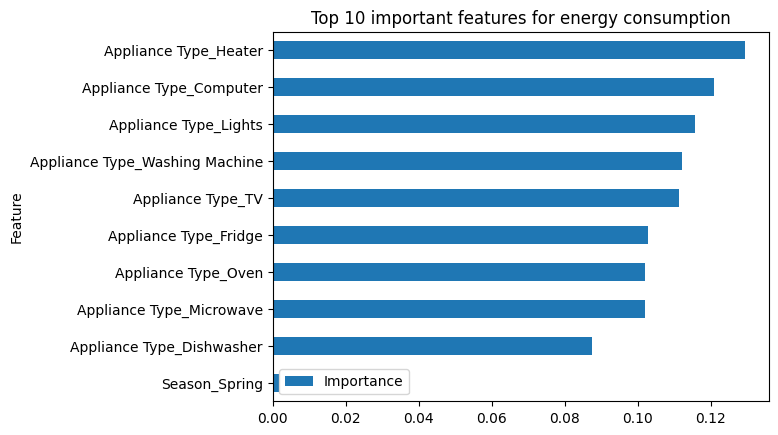

In [47]:
import matplotlib.pyplot as plt
feat_df.head(10).plot(kind="barh", x="Feature", y="Importance")
plt.gca().invert_yaxis()
plt.title("Top 10 important features for energy consumption")
plt.show()

Results show appliance type and temporal features as the dominant drivers of high energy consumption.

In [48]:
x = x.drop("Home ID", axis=1)

In [49]:
x.dtypes

,0
Outdoor Temperature (°C),float64
Household Size,int64
Year,int32
Month,int32
Day,int32
DayOfWeek,int32
Hour,int32
Appliance Type_Computer,bool
Appliance Type_Dishwasher,bool
Appliance Type_Fridge,bool


In [50]:
x = x.astype(int)

In [51]:
x = x.apply(pd.to_numeric)

In [52]:
x.dtypes


,0
Outdoor Temperature (°C),int64
Household Size,int64
Year,int64
Month,int64
Day,int64
DayOfWeek,int64
Hour,int64
Appliance Type_Computer,int64
Appliance Type_Dishwasher,int64
Appliance Type_Fridge,int64


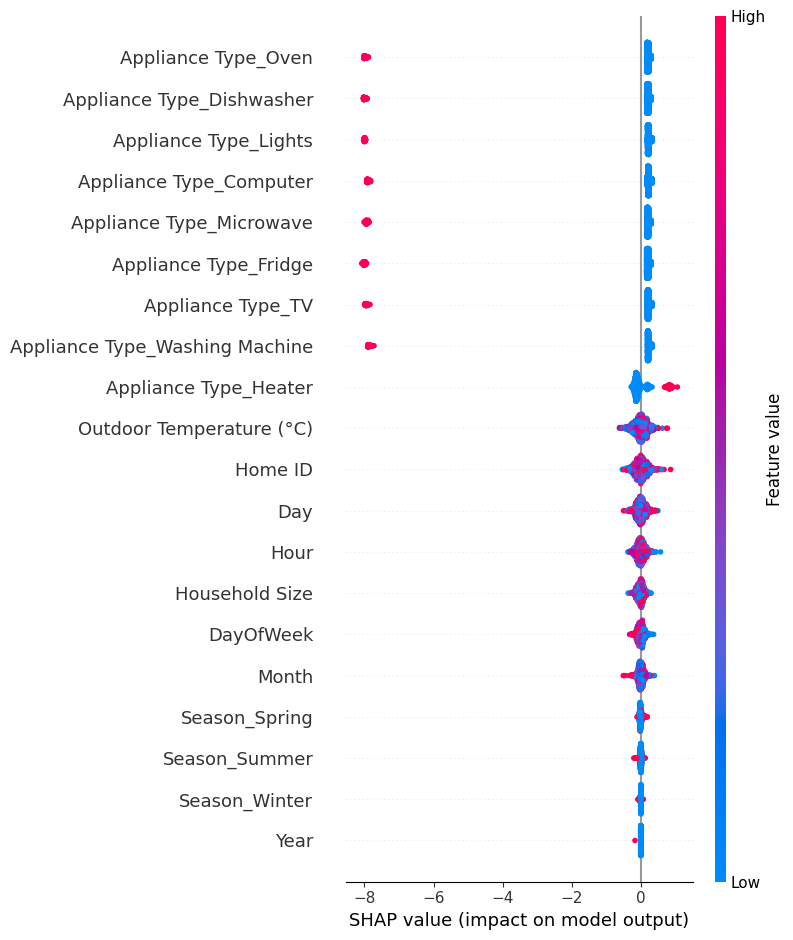

In [53]:
import shap

X_sample = X.sample(1000, random_state=42)

explainer = shap.TreeExplainer(xgb_final)
#shap_values = explainer.shap_values(X_sample)
shap_values = explainer(X_sample, check_additivity=False)

shap.summary_plot(shap_values, X_sample)


**The SHAP beeswarm plot** shows how each feature affects the model’s prediction: points on the right increase the predicted energy consumption, points on the left decrease it, and the color shows whether the feature value is high (red) or low (blue).

**Oven Example:** In the SHAP beeswarm plot, the feature Appliance Type_Oven shows both positive and negative contributions to energy prediction. For example, when the oven is used (red dots), the model sometimes predicts lower energy consumption, meaning that in the dataset, oven usage is correlated with lower total energy compared to other appliances like heaters or computers. This reflects learned data patterns, not real physical energy behavior.

**Ultra-Simple:** When the oven is ON, the model sometimes predicts lower energy because other appliances in the dataset consume more electricity. SHAP explains model behavior, not real-world physics.

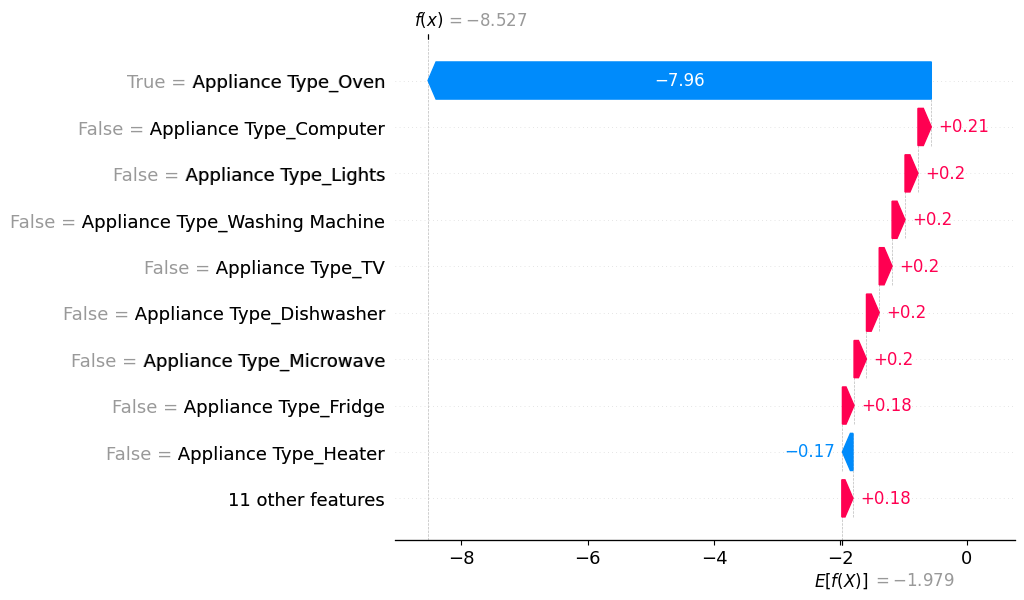

In [54]:
shap.plots.waterfall(shap_values[0])

**PHASE 1 — Production-Ready AI Pipeline**

In [61]:
import joblib
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [62]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [63]:
joblib.dump(xgb_final, "energy_model.pkl")

['energy_model.pkl']